# Bot or Not: From KNN Baseline to a Deployed LightGBM Model

This notebook trains a binary model to classify web traffic as:

- **HT**: human traffic
- **NHT**: non-human traffic

The final model is deployed through a FastAPI application.

## 1. Load and explore data

In [1]:
import pandas as pd

Data_PATH = "../data/"
df = pd.read_csv(Data_PATH + "clickdata.csv")

print("Shape:", df.shape)

Shape: (59782, 8)


In [2]:
# evaluate class imbalance to determine how to evaluate the model

print(df["ua_agent_class"].value_counts(normalize=True, dropna=False).mul(100))

ua_agent_class
Browser              59.397478
Robot                26.807400
Robot Mobile          8.556087
Browser Webview       3.010940
Hacker                1.968820
Special               0.240875
Mobile App            0.015055
Cloud Application     0.003345
Name: proportion, dtype: float64


### Missing values

Missing categorical values are kept as separate categories. This allows the model to learn whether missingness is informative.


In [3]:
# Inspect missing values. But dont convert them to empty strings. 

print(df.isna().sum())

epoch_ms                           0
session_id                         0
country_by_ip_address            248
region_by_ip_address            9896
url_without_parameters             0
referrer_without_parameters    44778
visitor_recognition_type           0
ua_agent_class                     0
dtype: int64


## 2. Define the binary target

The source dataset contains eight user-agent classes (ua_agent_class). I map them to the binary target as follows:

**HT — Human traffic**

- Browser
- Browser Webview
- Mobile App

**NHT — Non-human traffic**

- Robot
- Robot Mobile
- Hacker
- Cloud Application
- Special

In [4]:
human_classes = ["Browser", "Browser Webview", "Mobile App"]

df["is_nht"] = (~df["ua_agent_class"].isin(human_classes)).astype(int)

print(df["is_nht"].value_counts(normalize=True).round(3))

is_nht
0    0.624
1    0.376
Name: proportion, dtype: float64


In [5]:
# Label distribution
pd.crosstab(df["ua_agent_class"], df["is_nht"])

is_nht,0,1
ua_agent_class,,
Browser,35509,0
Browser Webview,1800,0
Cloud Application,0,2
Hacker,0,1177
Mobile App,9,0
Robot,0,16026
Robot Mobile,0,5115
Special,0,144


In [6]:
# Suspicious feature relationship
pd.crosstab(df["visitor_recognition_type"], df["is_nht"], normalize="index")

is_nht,0,1
visitor_recognition_type,,
ANONYMOUS,0.486102,0.513898
LOGGEDIN,1.000000,0.000000
RECOGNIZED,0.999921,0.000079


In [7]:
# Missingness by label
pd.crosstab(df["referrer_without_parameters"].isna(), df["is_nht"], normalize="index")

is_nht,0,1
referrer_without_parameters,,
False,0.997734,0.002266
True,0.499084,0.500916


## 3. Session-safe train/test split

Requests from the same session may be highly related. A random row-level split could place the same session in both training and test data, causing leakage.

I therefore split by `session_id`, keeping each session entirely in one dataset.

In [8]:
session_counts = df["session_id"].value_counts()

print("Total rows:", len(df))
print("Unique sessions:", df["session_id"].nunique())
print("Sessions with multiple requests:", (session_counts > 1).sum())
print("Maximum requests in one session:", session_counts.max())

Total rows: 59782
Unique sessions: 30816
Sessions with multiple requests: 3500
Maximum requests in one session: 412


In [9]:
from sklearn.model_selection import StratifiedGroupKFold

feature_columns = ["country_by_ip_address", "region_by_ip_address", "visitor_recognition_type"]

X = df[feature_columns]
y = df["is_nht"]
groups = df["session_id"]

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(splitter.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Save test set for next steps
X_test.to_pickle(Data_PATH + "X_test.pkl")
y_test.to_pickle(Data_PATH + "y_test.pkl")

In [10]:
train_sessions = set(groups.iloc[train_idx])
test_sessions = set(groups.iloc[test_idx])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Shared sessions:", len(train_sessions & test_sessions))

Training rows: 47825
Test rows: 11957
Shared sessions: 0


## 4. Features and preprocessing

The model uses three categorical features:

- `country_by_ip_address`
- `region_by_ip_address`
- `visitor_recognition_type`

I use the same features as the supplied baseline notebook. This allows me to focus on deployment and API engineering rather than extensive feature engineering.

`OneHotEncoder(handle_unknown="ignore")` is fitted only on the training data. This prevents preprocessing leakage and allows the model to handle unseen categories.

The encoder and classifier are stored in one pipeline so that training and API inference apply the same transformations.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        feature_columns,
    )
])

## 5. KNN: original baseline

The supplied notebook uses KNN. I retrain it with the binary target and session-safe split for a fair comparison.

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", KNeighborsClassifier(n_jobs=-1)),
])

knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['country_by_ip_address','region_by_ip_address','visitor_recognition_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [13]:
knn_pred = knn_pipeline.predict(X_test)
knn_probability = knn_pipeline.predict_proba(X_test)[:, 1]

## 6. LightGBM pipeline: improved and deployed model

LightGBM has a fixed model size and faster inference scaling than KNN, whose prediction cost grows with the training data.


In [14]:
from lightgbm import LGBMClassifier

lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

lightgbm_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", lightgbm_model),
])

lightgbm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['country_by_ip_address','region_by_ip_address','visitor_recognition_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, al

In [15]:
lightgbm_pred = lightgbm_pipeline.predict(X_test) # default threshold at 0.5
lightgbm_probability = (lightgbm_pipeline.predict_proba(X_test)[:, 1])

## 7. Evaluation

Macro F1 gives equal importance to HT and NHT. ROC-AUC and PR-AUC evaluate the predicted probabilities across different thresholds.

In [16]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

results = pd.DataFrame({
    "Model": ["KNN", "LightGBM"],
    "Accuracy": [accuracy_score(y_test, knn_pred), accuracy_score(y_test, lightgbm_pred)],
    "Macro F1": [f1_score(y_test, knn_pred, average="macro"), f1_score(y_test, lightgbm_pred, average="macro")],
    "ROC-AUC": [roc_auc_score(y_test, knn_probability), roc_auc_score(y_test, lightgbm_probability)],
    "PR-AUC": [average_precision_score(y_test, knn_probability), average_precision_score(y_test, lightgbm_probability)]
})

results.round(3)

,Model,Accuracy,Macro F1,ROC-AUC,PR-AUC
0,KNN,0.982,0.980,0.984,0.974
1,LightGBM,0.982,0.981,0.994,0.985


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lightgbm_pred, target_names=["HT", "NHT"],))

              precision    recall  f1-score   support

          HT       0.98      0.99      0.99      7464
         NHT       0.99      0.97      0.98      4493

    accuracy                           0.98     11957
   macro avg       0.98      0.98      0.98     11957
weighted avg       0.98      0.98      0.98     11957



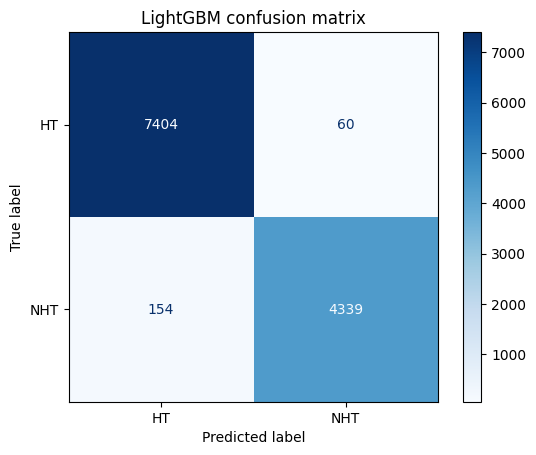

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, lightgbm_pred, display_labels=["HT", "NHT"], cmap="Blues")

plt.title("LightGBM confusion matrix")
plt.show()

### Threshold selection

In [19]:
from functions import evaluate_thresholds
import numpy as np

thresholds = np.arange(0.05, 1.0, 0.05)

threshold_results = evaluate_thresholds(
    y_true=y_test,
    probabilities=lightgbm_probability,
    thresholds=thresholds,
    false_positive_cost=50,
    false_negative_cost=1,
)

In [20]:
threshold_results.round(4)

,threshold,tp,fp,tn,fn,precision,recall,false_positive_rate,specificity,f1,predicted_positive_rate,business_cost
0,0.05,4473,1090,6374,20,0.8041,0.9955,0.1460,0.8540,0.8896,0.4653,54520
1,0.10,4381,147,7317,112,0.9675,0.9751,0.0197,0.9803,0.9713,0.3787,7462
2,0.15,4381,147,7317,112,0.9675,0.9751,0.0197,0.9803,0.9713,0.3787,7462
3,0.20,4380,147,7317,113,0.9675,0.9748,0.0197,0.9803,0.9712,0.3786,7463
4,0.25,4379,145,7319,114,0.9679,0.9746,0.0194,0.9806,0.9713,0.3784,7364
5,0.30,4367,116,7348,126,0.9741,0.9720,0.0155,0.9845,0.9730,0.3749,5926
6,0.35,4353,71,7393,140,0.9840,0.9688,0.0095,0.9905,0.9763,0.3700,3690
7,0.40,4349,61,7403,144,0.9862,0.9680,0.0082,0.9918,0.9770,0.3688,3194
8,0.45,4349,61,7403,144,0.9862,0.9680,0.0082,0.9918,0.9770,0.3688,3194
9,0.50,4339,60,7404,154,0.9864,0.9657,0.0080,0.9920,0.9759,0.3679,3154


In [21]:
threshold_results.sort_values("business_cost").head()

,threshold,tp,fp,tn,fn,precision,recall,false_positive_rate,specificity,f1,predicted_positive_rate,business_cost
17,0.90,4270,42,7422,223,0.990260,0.950367,0.005627,0.994373,0.969903,0.360626,2323
18,0.95,4268,42,7422,225,0.990255,0.949922,0.005627,0.994373,0.969669,0.360458,2325
15,0.80,4316,56,7408,177,0.987191,0.960605,0.007503,0.992497,0.973717,0.365644,2977
14,0.75,4316,56,7408,177,0.987191,0.960605,0.007503,0.992497,0.973717,0.365644,2977
16,0.85,4316,56,7408,177,0.987191,0.960605,0.007503,0.992497,0.973717,0.365644,2977


In [22]:
threshold_results[
    threshold_results["threshold"].round(2).isin([0.50, 0.90])
][
    [
        "threshold",
        "tp",
        "fp",
        "tn",
        "fn",
        "precision",
        "recall",
        "false_positive_rate",
        "predicted_positive_rate",
        "business_cost",
    ]
]

,threshold,tp,fp,tn,fn,precision,recall,false_positive_rate,predicted_positive_rate,business_cost
9,0.5,4339,60,7404,154,0.986361,0.965724,0.008039,0.367902,3154
17,0.9,4270,42,7422,223,0.990260,0.950367,0.005627,0.360626,2323


In [23]:
threshold_results_cost_10 = evaluate_thresholds(
    y_true=y_test,
    probabilities=lightgbm_probability,
    thresholds=thresholds,
    false_positive_cost=10,
    false_negative_cost=1,
)

In [24]:
threshold_results_cost_10.sort_values("business_cost").head(3)

,threshold,tp,fp,tn,fn,precision,recall,false_positive_rate,specificity,f1,predicted_positive_rate,business_cost
17,0.90,4270,42,7422,223,0.990260,0.950367,0.005627,0.994373,0.969903,0.360626,643
18,0.95,4268,42,7422,225,0.990255,0.949922,0.005627,0.994373,0.969669,0.360458,645
15,0.80,4316,56,7408,177,0.987191,0.960605,0.007503,0.992497,0.973717,0.365644,737


### Calibration

In [25]:
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

observed_rate, mean_predicted_probability = calibration_curve(
    y_test,
    lightgbm_probability,
    n_bins=10,
    strategy="quantile",
)

model_brier = brier_score_loss(y_test, lightgbm_probability)

base_rate = y_test.mean()
baseline_probabilities = np.full(len(y_test), base_rate)
baseline_brier = brier_score_loss(y_test, baseline_probabilities)

print("Positive base rate:", base_rate)
print("Model Brier score:", model_brier)
print("Constant-baseline Brier score:", baseline_brier)

Positive base rate: 0.3757631512921301
Model Brier score: 0.015669545783360234
Constant-baseline Brier score: 0.23456520542313777


In [26]:
mean_predicted_probability

array([1.69284011e-05, 2.14867226e-05, 3.96939498e-04, 4.19423157e-03,
       6.96287224e-03, 6.27658501e-02, 9.69249319e-01, 9.98731391e-01])

In [27]:
observed_rate

array([6.80272109e-04, 0.00000000e+00, 1.65700083e-03, 4.69483568e-03,
       6.61625709e-03, 6.62068966e-02, 9.67253286e-01, 1.00000000e+00])

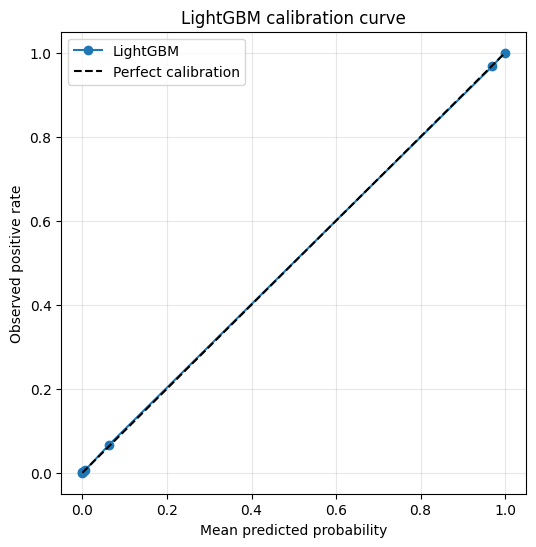

In [28]:
plt.figure(figsize=(6, 6))

plt.plot(mean_predicted_probability, observed_rate, marker="o", label="LightGBM")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("LightGBM calibration curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Why are the results so strong?

Both KNN and LightGBM achieve high scores, suggesting that the selected features already contain strong signals for separating HT from NHT.

The relationship between `visitor_recognition_type` and the target is examined below.

In [29]:
recognition_target = pd.crosstab(df["visitor_recognition_type"], df["is_nht"], normalize="index")

recognition_target.columns = ["HT", "NHT"]

recognition_target.round(3)

,HT,NHT
visitor_recognition_type,,
ANONYMOUS,0.486,0.514
LOGGEDIN,1.000,0.000
RECOGNIZED,1.000,0.000


In [30]:
df["visitor_recognition_type"].value_counts(normalize=True,dropna=False).mul(100)

visitor_recognition_type
ANONYMOUS     73.117326
RECOGNIZED    21.058178
LOGGEDIN       5.824496
Name: proportion, dtype: float64

The results show that:

- All `LOGGEDIN` requests are HT.
- Almost all `RECOGNIZED` requests are HT.
- Almost all NHT requests are `ANONYMOUS`.
- Anonymous traffic still contains both HT and NHT, so the model also uses country and region to separate them.

This strong relationship explains why both KNN and LightGBM perform well with only three features.

However, this may be specific to the simulated dataset. In production, bot behaviour and recognition patterns may change. The model should therefore be monitored for feature and performance drift.

A more detailed error analysis is performed in 02_erro_analysis notebook. 

## 8. Save the deployed model

The preprocessing and model are saved together to ensure consistent transformations during API inference. The selected threshold based on bussiness costs of 50 for false_positive and 1 for false_negative is also saved with the model. 

In [31]:
import joblib

selected_threshold = 0.9

artifact = {
    "pipeline": lightgbm_pipeline,
    "threshold": selected_threshold,
    "feature_names": list(X_train.columns),
    "false_positive_cost": 50,
    "false_negative_cost": 1,
}

model_path = ("../models/bot_detection_pipeline.joblib")

joblib.dump(artifact, model_path)

['../models/bot_detection_pipeline.joblib']

In [32]:
# verify if the model is saved

artifact = joblib.load(model_path)

loaded_pipeline = artifact["pipeline"]

original = lightgbm_pipeline.predict_proba(X_test.head())[:, 1]
loaded = loaded_pipeline.predict_proba(X_test.head())[:, 1]

assert (original == loaded).all()

print("Model saved and verified.")

Model saved and verified.


## 9. Limitations

The model uses only country, region, and visitor recognition type. Their strong relationship with the target may be specific to this simulated dataset and may weaken in production.

The HT/NHT mapping, particularly for `Mobile App` and `Special`, is a business assumption that should be confirmed with the data owner.